# Smartphone Addiction Analysis

In [7]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import optuna
import warnings
warnings.filterwarnings('ignore')
print('Current dir:', os.getcwd())


Current dir: c:\Users\Asus\OneDrive\Desktop\Smartphone Addiction Prediction Data\notebooks


---

## Phase 1: Load Data

In [8]:
# Find the data file path
data_path = 'data/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv'
if not os.path.exists(data_path):
    data_path = '../data/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv'
    if not os.path.exists(data_path):
        data_path = os.path.expanduser('~/OneDrive/Desktop/Smartphone Addiction Prediction Data/data/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')
print(f'Using: {data_path}')
df = pd.read_csv(data_path)
print(f'Shape: {df.shape}')
df.head()

Using: ../data/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv
Shape: (7500, 16)


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


---

## Phase 2: Data Preprocessing

In [9]:
df = df.drop(columns=['transaction_id', 'user_id'])
print('Dropped: transaction_id, user_id')

Dropped: transaction_id, user_id


In [10]:
print(f'Missing before: {df.isnull().sum().sum()}')
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = IterativeImputer(max_iter=10, random_state=42).fit_transform(df[num_cols])
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print(f'Missing after: {df.isnull().sum().sum()}')

Missing before: 819
Missing after: 0


In [11]:
dups = df.duplicated().sum()
print(f'Duplicates: {dups}')
df = df.drop_duplicates()

Duplicates: 0


In [12]:
def winsorize(col, lower=0.01, upper=0.99):
    return col.clip(col.quantile(lower), col.quantile(upper))
for col in ['notifications_per_day', 'app_opens_per_day', 'daily_screen_time_hours']:
    df[col] = winsorize(df[col])
print(f'Final Shape: {df.shape}')

Final Shape: (7500, 14)


---

## Phase 3: Exploratory Data Analysis

In [13]:
print('Addiction Level Distribution:')
print(df['addiction_level'].value_counts())
print('Addicted Label Distribution:')
print(df['addicted_label'].value_counts())

Addiction Level Distribution:
addiction_level
Moderate    3693
Severe      2434
Mild        1373
Name: count, dtype: int64
Addicted Label Distribution:
addicted_label
1.0    5308
0.0    2192
Name: count, dtype: int64


In [14]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499889,3.273484,2.014183,3.242420,6.737561,134.258933,97.831467,9.243827,0.707733
std,5.197108,2.607667,1.585342,1.146039,1.600765,1.283605,66.542653,48.402349,2.718281,0.454835
min,18.000000,3.079900,0.500000,0.000000,0.500000,4.500000,22.000000,16.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,11.910100,6.000000,4.000000,6.000000,9.000000,248.000000,179.000000,14.880000,1.000000


---

## Phase 4: Feature Engineering

In [15]:
df['gaming_ratio'] = df['gaming_hours'] / df['daily_screen_time_hours']
df['social_ratio'] = df['social_media_hours'] / df['daily_screen_time_hours']
df['weekend_vs_weekday_ratio'] = df['weekend_screen_time'] / df['daily_screen_time_hours']

# New Intensity Features
df['usage_intensity'] = df['app_opens_per_day'] / df['daily_screen_time_hours']
df['notification_intensity'] = df['notifications_per_day'] / df['daily_screen_time_hours']
df['productivity_ratio'] = df['work_study_hours'] / (df['social_media_hours'] + 0.5) # Avoid div by zero

print('Created new features: usage_intensity, notification_intensity, productivity_ratio')

Created: gaming_ratio, social_ratio, weekend_vs_weekday_ratio


In [16]:
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['stress_level_enc'] = df['stress_level'].map(stress_map)
df['academic_work_impact_enc'] = df['academic_work_impact'].map({'No': 0, 'Yes': 1})
addiction_map = {'Mild': 0, 'Moderate': 1, 'Severe': 2}
df['addiction_level_enc'] = df['addiction_level'].map(addiction_map)
df = pd.get_dummies(df, columns=['gender'], drop_first=True)
print('Encoded: stress_level, academic_work_impact, addiction_level, gender')

Encoded: stress_level, academic_work_impact, addiction_level, gender


In [17]:
features = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
            'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day',
            'weekend_screen_time', 'stress_level_enc', 'academic_work_impact_enc',
            'gaming_ratio', 'social_ratio', 'weekend_vs_weekday_ratio',
            'usage_intensity', 'notification_intensity', 'productivity_ratio',
            'gender_Male']
X = df[features]
y = df['addiction_level_enc']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Final Training Features: {len(features)}')

Scaled features with RobustScaler


---

## Phase 5: Predictive Modeling

In [18]:
features = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
            'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day',
            'weekend_screen_time', 'stress_level_enc', 'academic_work_impact_enc',
            'gaming_ratio', 'social_ratio', 'weekend_vs_weekday_ratio',
            'gender_Male']
X = df[features]
y = df['addiction_level_enc']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (6000, 15), Test: (1500, 15)


In [19]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss', verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall': recall_score(y_test, y_pred, average='macro')
    }
    print(f'{name}: Accuracy={results[name]["accuracy"]:.4f}, F1={results[name]["f1_macro"]:.4f}')

LogisticRegression: Accuracy=0.4847, F1=0.4578
RandomForest: Accuracy=0.4993, F1=0.5112
XGBoost: Accuracy=0.5167, F1=0.5235
LightGBM: Accuracy=0.5127, F1=0.5236


---

## Phase 6: Model Evaluation

In [20]:
best_model_name = max(results, key=lambda x: results[x]['f1_macro'])
print(f'Best Model: {best_model_name}')
best_model = models[best_model_name]

Best Model: LightGBM


In [21]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Mild', 'Moderate', 'Severe']))

              precision    recall  f1-score   support

        Mild       0.53      0.61      0.57       275
    Moderate       0.51      0.48      0.49       738
      Severe       0.51      0.51      0.51       487

    accuracy                           0.51      1500
   macro avg       0.52      0.53      0.52      1500
weighted avg       0.51      0.51      0.51      1500



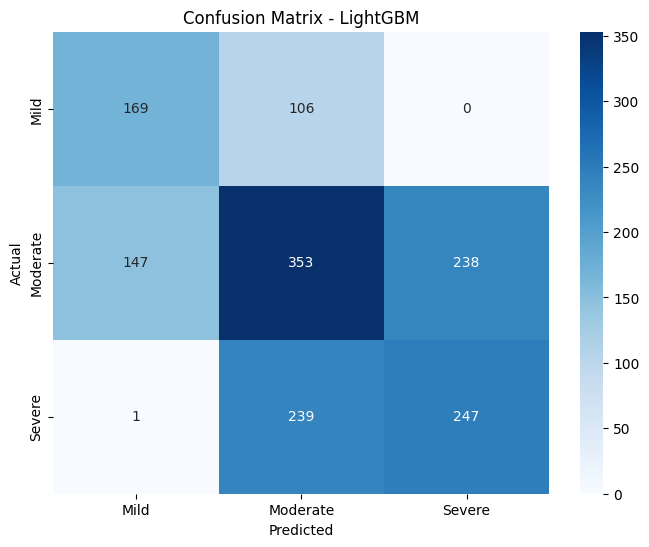

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Mild', 'Moderate', 'Severe'],
            yticklabels=['Mild', 'Moderate', 'Severe'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

---

## Phase 7: Clustering

In [23]:
cluster_features = ['daily_screen_time_hours', 'gaming_hours', 'social_media_hours',
                    'sleep_hours', 'notifications_per_day']
X_cluster = df[cluster_features]
X_cluster_scaled = RobustScaler().fit_transform(X_cluster)

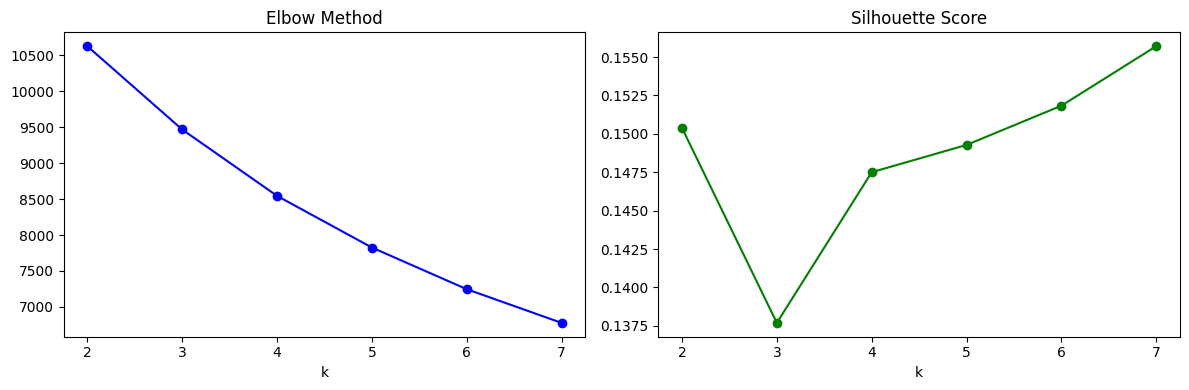

In [24]:
k_range = range(2, 8)
inertias = []
silhouettes = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, kmeans.labels_))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[1].plot(k_range, silhouettes, 'go-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()

In [25]:
optimal_k = list(k_range)[np.argmax(silhouettes)]
print(f'Optimal k: {optimal_k}')
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)
print('Cluster Profiles:')
df.groupby('cluster')[cluster_features].mean().round(2)

Optimal k: 7
Cluster Profiles:


,daily_screen_time_hours,gaming_hours,social_media_hours,sleep_hours,notifications_per_day
cluster,,,,,
0,0.30,0.43,0.43,-0.49,-0.15
1,-0.43,-0.41,-0.24,-0.29,-0.51
2,0.22,-0.59,-0.06,-0.09,0.57
3,0.27,0.34,-0.54,0.46,-0.14
4,0.42,-0.42,0.42,0.38,-0.44
5,-0.45,0.22,0.50,0.51,0.23
6,-0.35,0.36,-0.41,-0.39,0.50


---

## Phase 8: Summary

In [26]:
print('='*50)
print('PHASE SUMMARY')
print('='*50)
print(f'Data Shape: {df.shape}')
print(f'Best Model: {best_model_name}')
print(f'Accuracy: {results[best_model_name]["accuracy"]:.4f}')
print(f'F1 Score (Macro): {results[best_model_name]["f1_macro"]:.4f}')
print(f'Optimal Clusters: {optimal_k}')
print('='*50)

PHASE SUMMARY
Data Shape: (7500, 22)
Best Model: LightGBM
Accuracy: 0.5127
F1 Score (Macro): 0.5236
Optimal Clusters: 7


---
## Phase 7: Advanced Model Optimization (SMOTE & Optuna)

In [ ]:
# Step 1: Handle Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f'Original training set shape: {y_train.value_counts().to_dict()}')
print(f'Resampled training set shape: {y_train_res.value_counts().to_dict()}')

In [ ]:
# Step 2: Hyperparameter Tuning with Optuna for LightGBM
def objective(trial):
    param = {
        'objective': 'multiclass',
        'metric': 'multi_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'num_class': 3,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }

    gbm = lgb.LGBMClassifier(**param, random_state=42)
    gbm.fit(X_train_res, y_train_res)
    preds = gbm.predict(X_test)
    f1 = f1_score(y_test, preds, average='macro')
    return f1

print('Starting Optuna optimization...')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # Reduced trials for speed in demonstration

print('Best trial:', study.best_trial.params)

In [ ]:
# Step 3: Train and Evaluate the Best Model
best_params = study.best_trial.params
best_gbm = lgb.LGBMClassifier(**best_params, objective='multiclass', random_state=42, verbose=-1)
best_gbm.fit(X_train_res, y_train_res)

y_pred_best = best_gbm.predict(X_test)
print('--- Final Optimized Model Performance ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(classification_report(y_test, y_pred_best, target_names=['Mild', 'Moderate', 'Severe']))

---
## Phase 8: Final Ensemble Stacking Classifier

In [ ]:
from sklearn.ensemble import StackingClassifier

# Use best params from Optuna for LightGBM (we already have them in best_params)
# For demonstration, we'll also define quick tuned XGBoost params

base_models = [
    ('lgb', lgb.LGBMClassifier(**best_params, random_state=42, verbose=-1)),
    ('xgb', xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='mlogloss')),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, class_weight='balanced'))
]

stack_model = StackingClassifier(
    estimators=base_models, 
    final_estimator=LogisticRegression(),
    cv=5
)

print('Training Stacking Ensemble (this may take a minute)...')
stack_model.fit(X_train_res, y_train_res)

y_pred_stack = stack_model.predict(X_test)
print('--- Final Stacking Ensemble Performance ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_stack):.4f}')
print(classification_report(y_test, y_pred_stack, target_names=['Mild', 'Moderate', 'Severe']))

In [ ]:
# Feature Importance Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Using LightGBM from the stack to show feature importance
lgb_model = stack_model.named_estimators_['lgb']
importance_df = pd.DataFrame({'feature': features, 'importance': lgb_model.feature_importances_})
importance_df = importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Feature Importance (LightGBM from Ensemble)')
plt.show()